In [38]:
from pathlib import Path
import os

os.chdir(Path.cwd().parent)

import numpy as np

import pandas as pd
import random as random
import matplotlib.pyplot as plt
import math
from src.funciones import media_muestral
from src.funciones import varianza_muestral
from scipy.stats import norm 

In [3]:
semilla = 223
rng = np.random.default_rng(semilla)


Usamos $\lambda = 100$ y $\mu = 10$, por lo que $\nu=\frac{\lambda}{\mu}=10$

In [4]:
nu = 10

Una Variable Aleatoria $X$ que distribuye a una Poisson($\nu$) tiene distribución discreta:
$$
\mathbb{P}_\nu (X = k) = \frac{\nu ^k e ^{-\nu}}{k!}
$$

Por lo que una MAS de $n$ variables aleatorias tiene función de verosimilitud $L$
$$
L(x_1,...,x_n, \nu) = \prod_{i=1}^n \frac{\nu ^k e ^{-\nu}}{k!}
$$

Así, su función de log-verosimilitud $l$ esta dada por

$$
l(x_1,...,x_n, \nu) = \sum_{i=1}^n \operatorname{log}(\frac{\nu ^{x_i} e ^{-\nu}}{x_i!}) = \sum_{i=1}^n(x_i\operatorname{log}\nu - \nu - \operatorname{log}(x_i!)) = (\operatorname{log} \nu) (\sum_{i=1}^n x_i) - n\nu - \sum_{i=1}^n \operatorname{log}(x_i!)
$$


Veamos sus primeras dos derivadas para una muestra de tamaño 1

$$
\frac{\partial l}{\partial \nu} = \frac{x}{\nu} - n
$$

$$
\frac{\partial ^2 l}{\partial ^2 \nu} = -\frac{x}{\nu^2}
$$

Así su información de fisher está dada por 

$$
I(\nu) = -\mathbb{E}[\frac{\partial ^2 l}{\partial ^2 \nu}]  = \frac{1}{\nu ^2} \mathbb{E}[X] = \frac{1}{\nu}
$$

Para una muestra de tamaño n la información de fisher será

$$
I_n(\nu) = \frac{n}{\nu}
$$

Finalmente, dado $T$ un estimador de $\nu$ insesgado (con muestra de tamaño n), se tiene que su varianza es acotada inferiormente por la cota de Cramer-Rao $\operatorname{CICR}(\nu)$

$$
\mathbb{V}[T_n] \geq \operatorname{CICR}(\nu) = I_n^{-1}(\nu) = \frac{\nu}{n}
$$

Sea $\overline{X}_n=\frac{1}{n}\sum_{i=1}^n X_i$ el estimador que usamos en la parte 2
$$\mathbb{V}(\overline{X}_n) = \frac{1}{n^2} \sum_{i=1}^n \mathbb{V}(X_i)= \frac{1}{n^2} \sum_{i=1}^n \nu =  \frac{n \nu}{n^2} = \frac{\nu}{n}$$
Coincide con la cota inferior de Cramer-Rao. Por lo que es un estimador eficiente


In [6]:
n , N = 1000 , 1000

In [ ]:
#un array que es el estimador
rs_poisson= rng.poisson(lam=10,size=(N,n))
sumas_fila= np.sum(rs_poisson,axis=1)
nu_n = sumas_fila/n

In [ ]:
#ahora la media y varianza del estimador
media = np.mean(nu_n)
varianza = np.var(nu_n)

In [40]:
import os
print(os.getcwd())

c:\Users


FileNotFoundError: [Errno 2] No such file or directory: '../results/normalidad_n10.png'

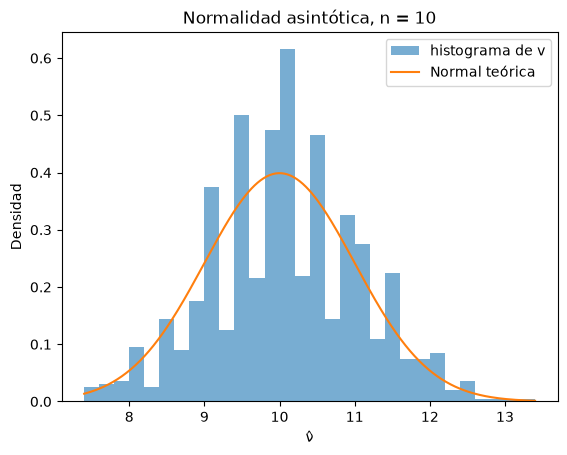

In [39]:
tamaños = [10,50,100,500,1000,5000,10000]
medias =[]
varianzas=[]
cotas = []
for k in tamaños:
    rs_poisson= rng.poisson(lam=nu,size=(N,k))
    sumas_fila= np.sum(rs_poisson,axis=1)
    nu_n = sumas_fila/k
    media = np.mean(nu_n)
    varianza = np.var(nu_n)
    cota= nu/k

    cotas.append(cota)
    medias.append(media)
    varianzas.append(varianza)

    x = np.linspace(nu_n.min(), nu_n.max(), 300)
    plt.hist(nu_n, bins=30,density=True,alpha=0.6,label="histograma de v")
    plt.plot(x, norm.pdf(x, loc=nu, scale=np.sqrt(cota)), label="Normal teórica")
    plt.xlabel("ν̂")
    plt.ylabel("Densidad")
    plt.title(f"Normalidad asintótica, n = {k}")
    plt.legend()
    plt.savefig(f"../results/normalidad_n{k}.png")
    plt.show()


In [34]:
vc = []

for i in range(len(varianzas)):
    vc.append(varianzas[i] / cotas[i])

In [35]:
df = pd.DataFrame({
    "n" : tamaños,
    "Media" : medias,
    "Varianza" : varianzas,
    "Cota" : cotas,
    "varianza/Cota": vc
})
df

,n,Media,Varianza,Cota,varianza/Cota
0,10,9.996400,1.005407,1.000,1.005407
1,50,9.985680,0.215740,0.200,1.078699
2,100,9.996430,0.095352,0.100,0.953520
3,500,9.999568,0.020448,0.020,1.022411
4,1000,10.005604,0.009814,0.010,0.981396
5,5000,9.998929,0.001965,0.002,0.982314
6,10000,9.997973,0.000970,0.001,0.970225


In [20]:
print(cotas)

[1.0, 0.1, 0.01, 0.002, 0.001]
